# 🔆 Overview

This notebook adds an 'onset indicator' column that shows whether the observation is the first signal of hypo/hyperglycemic event in the synthetic data.

**Additional Changes**
* Column 'normal_range' is changed to 'unsafe' for easier interpretability of model performance.
* Column 'dogID' is added for Cross Validation

**The final dataframes will be used for model development**

In [1]:
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
pd.set_option("display.max_rows", 500)

In [4]:
dataset_path = "/content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/final_data/updated"
files = os.listdir(dataset_path)
files

['all_df.csv',
 'cv_test_df.csv',
 'cv_train_df.csv',
 'cv_train_final.csv',
 'minute_canine_ar.csv',
 'minute_canine_ar.pkl',
 'all_cv_df.csv',
 'train_onset_all_df.csv',
 'train_onset_final.csv',
 '[Please Read] Final Data Documentation.gdoc',
 'cv_df_final_0329.csv']

In [5]:
# reading function that automatically deals with datetime object
def import_csv(data_path, filename):
    df = pd.read_csv(os.path.join(data_path, filename))
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    return df

In [6]:
all_df =  import_csv(dataset_path, "cv_df_final_0329.csv")

In [7]:
display(all_df.head(2))
display(all_df.dtypes.reset_index(name = "data types"))

,ID,timestamp,observed_glucose,glucose_1min,is_observed,glucose_1min_noisy
0,canine1-001,2025-11-01 05:51:00,375.0,375.0,True,375.000000
1,canine1-001,2025-11-01 05:52:00,NaN,375.0,False,375.056846


,index,data types
0,ID,object
1,timestamp,datetime64[ns]
2,observed_glucose,float64
3,glucose_1min,float64
4,is_observed,bool
5,glucose_1min_noisy,float64


## 🧹Cleaning dataframe

* drop observed_glucose since the is_observed column will tell
* change in names / additional columns
  * glucose: glucose_1_min_noisy
  * glucose_syn: glucose level coming from synthetic data
  * observed: comes from is_observed in boolean
  * glucose_category newly added
  * unsafe: newly added. indicates whether the glucose category is in unsafe range
  * dogID: indicates subject ID (different from subgroupID)

* 'glucose_syn' and 'observed' columns are in the dataframe to provide information, rather than to serve as model inputs

👉 **For the binary model, the label for prediction should be normal_range and for multi-class classification model, the label should be glucose_category**

In [10]:

# drop observed_glucose
df_cleaned = all_df.drop(columns=["observed_glucose"])

# rename columns
df_cleaned = df_cleaned.rename(
    columns= {
        "is_observed": "observed",
        "glucose_1min_noisy": "glucose",
        "glucose_1min": "glucose_syn"
        })

# adding glucose_category
df_cleaned["glucose_category"] = np.select(

    # set ranges
    [
        df_cleaned["glucose"] < 65,
        df_cleaned["glucose"] > 250
    ],
    # set categories
    [
        "hypoglycemia",
        "hyperglycemia"
    ],
    # other cases
    default = "normal"
)

# adding unsafe column
df_cleaned["unsafe"] = df_cleaned["glucose_category"] != "normal"

# adding dogID column
df_cleaned["dogID"] = df_cleaned["ID"].str.split("-").str[0]

# cleaning column order
df_cleaned = df_cleaned[["dogID", "ID", "timestamp", "glucose", "glucose_category", "unsafe", "glucose_syn", "observed"]]

# make sure that the dataframe is ordered by timestamp
df_cleaned = df_cleaned.sort_values(["ID", "timestamp"])

In [12]:
display(df_cleaned.head(2))

# check data types
df_cleaned.dtypes.reset_index(name = "data types")

,dogID,ID,timestamp,glucose,glucose_category,unsafe,glucose_syn,observed
0,canine1,canine1-001,2025-11-01 05:51:00,375.000000,hyperglycemia,True,375.0,True
1,canine1,canine1-001,2025-11-01 05:52:00,375.056846,hyperglycemia,True,375.0,False


,index,data types
0,dogID,object
1,ID,object
2,timestamp,datetime64[ns]
3,glucose,float64
4,glucose_category,object
5,unsafe,bool
6,glucose_syn,float64
7,observed,bool


## ➕ Adding "onset" column

* onset_observed: real onset
* onset: onset with synthetic data

* onset = True condition (should satisfy all)

  : Cases where
  * previous glucose category is normal ***and***
  * current glucose category is either hypo/hyperglycemia
  * data is not the starting point
  
* onset = False

  : Cases where
  * previous glucose category is the same as the current
  * glucose category is either hypo/hyperglycemia but the data is the starting point of the subset

* onset_observed = True
  
  : Cases where
  * previous **observed** category is normal
  * **observed** = True
  * glucose category is ether hypo/hyperglycemia
  * data is not the starting point

In [18]:
onset_df = df_cleaned.copy()

# creating previous category column for comparison
onset_df["prev_category"] = onset_df.groupby("ID")["glucose_category"].shift(1)

# creating onset column
onset_df["onset"] = (
    onset_df["glucose_category"].isin(["hypoglycemia", "hyperglycemia"])
    & (onset_df["prev_category"] == "normal")
)

In [19]:
# onset_observed
observed = onset_df[onset_df["observed"] == True].copy()
observed["prev_category_observed"] = observed.groupby("ID")["glucose_category"].shift(1)

# merging back
onset_df = onset_df.merge(
    observed[["ID", "timestamp", "prev_category_observed"]],
    on = ["ID", "timestamp"],
    how = "left"
)

# now creating onset_observed column
onset_df["onset_observed"] = (
    (onset_df["observed"] == True)
    & (onset_df["glucose_category"].isin(["hypoglycemia", "hyperglycemia"]))
    & (onset_df["prev_category_observed"] == "normal")
)

onset_df = onset_df[["dogID", "ID", "timestamp", "glucose", "glucose_category", "unsafe", "observed", "onset", "onset_observed", "glucose_syn", "prev_category", "prev_category_observed"]]

onset_df.head()

,dogID,ID,timestamp,glucose,glucose_category,unsafe,observed,onset,onset_observed,glucose_syn,prev_category,prev_category_observed
0,canine1,canine1-001,2025-11-01 05:51:00,375.000000,hyperglycemia,True,True,False,False,375.0,NaN,NaN
1,canine1,canine1-001,2025-11-01 05:52:00,375.056846,hyperglycemia,True,False,False,False,375.0,hyperglycemia,NaN
2,canine1,canine1-001,2025-11-01 05:53:00,374.714980,hyperglycemia,True,False,False,False,375.0,hyperglycemia,NaN
3,canine1,canine1-001,2025-11-01 05:54:00,375.045685,hyperglycemia,True,False,False,False,375.0,hyperglycemia,NaN
4,canine1,canine1-001,2025-11-01 05:55:00,375.676269,hyperglycemia,True,False,False,False,375.0,hyperglycemia,NaN


In [20]:
display(onset_df[onset_df["onset"] == True].head(2))
display(onset_df[onset_df["onset_observed"] == True].head(2))

,dogID,ID,timestamp,glucose,glucose_category,unsafe,observed,onset,onset_observed,glucose_syn,prev_category,prev_category_observed
609,canine1,canine1-001,2025-11-01 16:00:00,250.958497,hyperglycemia,True,False,True,False,250.777778,normal,NaN
685,canine1,canine1-001,2025-11-01 17:16:00,251.689776,hyperglycemia,True,False,True,False,252.200000,normal,NaN


,dogID,ID,timestamp,glucose,glucose_category,unsafe,observed,onset,onset_observed,glucose_syn,prev_category,prev_category_observed
610,canine1,canine1-001,2025-11-01 16:01:00,252.0,hyperglycemia,True,True,False,True,252.0,hyperglycemia,normal
691,canine1,canine1-001,2025-11-01 17:22:00,259.0,hyperglycemia,True,True,False,True,259.0,hyperglycemia,normal


### ⏰ Time difference between the actual vs synthetic onset

24% of the synthetic onset points are introduced due to data synthesis

In [ ]:
episodes = train_df[train_df["normal_range"] == False].copy()
episodes = episodes[["ID", "timestamp", "observed", "glucose_category", "prev_category", "prev_category_observed", "onset", "onset_observed"]]

episodes["new_event"] = (episodes["prev_category"] != episodes["glucose_category"]) & ((episodes["prev_category"]).notna())
episodes["episode_id"] = episodes["new_event"].cumsum()

episodes[episodes["new_event"]].head()

,ID,timestamp,observed,glucose_category,prev_category,prev_category_observed,onset,onset_observed,new_event,episode_id
205,canine2-001,2025-04-09 16:21:00,False,hyperglycemia,normal,NaN,True,False,True,1
370,canine2-001,2025-04-09 19:06:00,False,hyperglycemia,normal,NaN,True,False,True,2
376,canine2-001,2025-04-09 19:12:00,False,hyperglycemia,normal,NaN,True,False,True,3
463,canine2-001,2025-04-09 20:39:00,False,hyperglycemia,normal,NaN,True,False,True,4
523,canine2-001,2025-04-09 21:39:00,False,hypoglycemia,normal,NaN,True,False,True,5


In [ ]:
synthetic_onset = (
    episodes[episodes["onset"] == True]
    .groupby(["ID", "episode_id"])["timestamp"]
    .min()
    .reset_index(name = "synthetic_onset")
)

observed_onset = (
    episodes[episodes["onset_observed"] == True]
    .groupby(["ID", "episode_id"])["timestamp"]
    .min()
    .reset_index(name = "observed_onset")
)

# merging
onset_comparison = synthetic_onset.merge(
    observed_onset,
    on = ["ID", "episode_id"],
    how = "left"
)

onset_comparison["synthetic_onset"] = pd.to_datetime(onset_comparison["synthetic_onset"])
onset_comparison["observed_onset"] = pd.to_datetime(onset_comparison["observed_onset"])

delta = onset_comparison["observed_onset"] - onset_comparison["synthetic_onset"]
onset_comparison["onset_delta"] = delta.dt.total_seconds() / 60

onset_comparison["observed_onset"].isna().mean()

np.float64(0.24122137404580152)

In [ ]:
synthetic_onset.describe()
observed_onset.describe()

,episode_id,observed_onset
count,497.000000,497
mean,320.857143,2025-09-18 02:38:22.454728448
min,1.000000,2025-03-26 12:10:00
25%,157.000000,2025-04-19 06:44:00
50%,312.000000,2025-10-29 07:30:00
75%,482.000000,2026-01-04 17:42:00
max,655.000000,2026-03-06 13:46:00
std,186.731829,NaN


In [ ]:
valid_onset_comparison = onset_comparison.dropna()

valid_onset_comparison["onset_delta"].describe()

,onset_delta
count,497.000000
mean,6.613682
std,5.892147
min,0.000000
25%,2.000000
50%,6.000000
75%,10.000000
max,43.000000


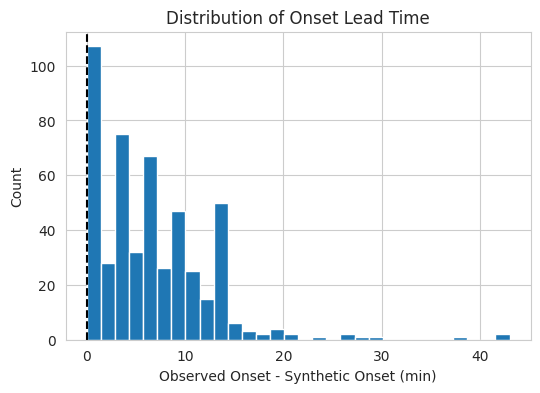

In [ ]:
plt.figure(figsize = (6, 4))
plt.hist(valid_onset_comparison["onset_delta"], bins = 30)
plt.title("Distribution of Onset Lead Time")
plt.xlabel("Observed Onset - Synthetic Onset (min)")
plt.ylabel("Count")
plt.axvline(0, linestyle = "--", color = "black")
plt.show()

### 📊 Histogram of onset distribution

In [ ]:
onset_counts = (
    train_df[train_df["onset"]]
    .groupby("ID")
    .size()
    .reset_index(name = "onset_counts")
)
onset_counts.describe()

,onset_counts
count,180.000000
mean,3.638889
std,3.486228
min,1.000000
25%,1.000000
50%,2.000000
75%,4.250000
max,20.000000


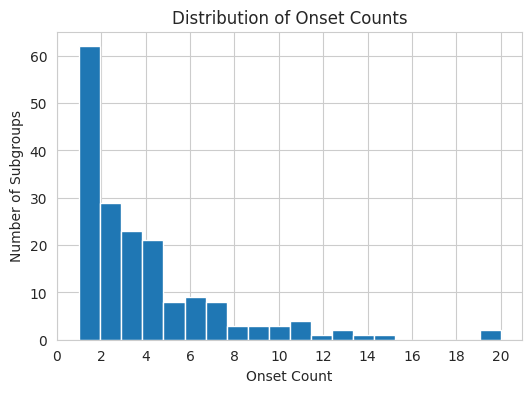

In [ ]:
plt.figure(figsize = (6, 4))
plt.hist(onset_counts["onset_counts"], bins = 20)
plt.title("Distribution of Onset Counts")
plt.xlabel("Onset Count")
plt.xticks(range(0, 21, 2))
plt.ylabel("Number of Subgroups")
plt.show()

In [ ]:
total_unsafe = (
    train_df[train_df["normal_range"] == False]
    .groupby("ID")
    .size()
    .reset_index(name = "total_unsafe")
)

onset_prop = onset_counts.merge(
    total_unsafe,
    on = "ID",
    how = "outer"
    ).fillna(0)

onset_prop["onset_prop"] = onset_prop["onset_counts"] / onset_prop["total_unsafe"]

In [ ]:
onset_prop.describe()

,onset_counts,total_unsafe,onset_prop
count,247.000000,247.000000,247.000000
mean,2.651822,958.898785,0.007958
std,3.387001,1260.442819,0.034989
min,0.000000,2.000000,0.000000
25%,0.000000,346.000000,0.000000
50%,1.000000,556.000000,0.002262
75%,4.000000,914.500000,0.006042
max,20.000000,9993.000000,0.500000


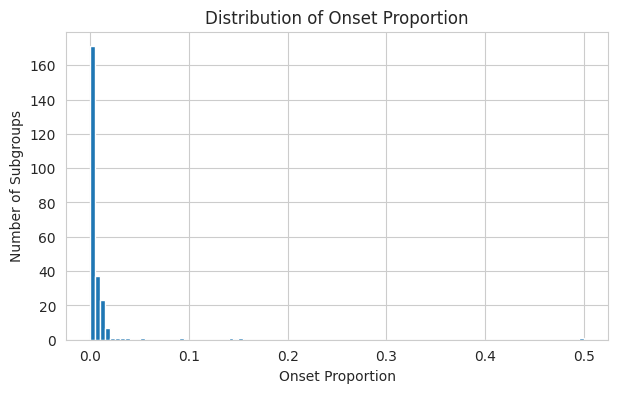

In [ ]:
plt.figure(figsize = (7, 4))
plt.hist(onset_prop["onset_prop"], bins = 100)
plt.title("Distribution of Onset Proportion")
plt.xlabel("Onset Proportion")
plt.ylabel("Number of Subgroups")
plt.show()

### 🧰 Saving dataframes with onset indicator

In [21]:
onset_df.head()

,dogID,ID,timestamp,glucose,glucose_category,unsafe,observed,onset,onset_observed,glucose_syn,prev_category,prev_category_observed
0,canine1,canine1-001,2025-11-01 05:51:00,375.000000,hyperglycemia,True,True,False,False,375.0,NaN,NaN
1,canine1,canine1-001,2025-11-01 05:52:00,375.056846,hyperglycemia,True,False,False,False,375.0,hyperglycemia,NaN
2,canine1,canine1-001,2025-11-01 05:53:00,374.714980,hyperglycemia,True,False,False,False,375.0,hyperglycemia,NaN
3,canine1,canine1-001,2025-11-01 05:54:00,375.045685,hyperglycemia,True,False,False,False,375.0,hyperglycemia,NaN
4,canine1,canine1-001,2025-11-01 05:55:00,375.676269,hyperglycemia,True,False,False,False,375.0,hyperglycemia,NaN


In [22]:
df_final = onset_df[["dogID", "ID", "timestamp", "glucose", "glucose_category", "unsafe", "observed", "onset", "onset_observed"]]

In [23]:
df_final.head()

,dogID,ID,timestamp,glucose,glucose_category,unsafe,observed,onset,onset_observed
0,canine1,canine1-001,2025-11-01 05:51:00,375.000000,hyperglycemia,True,True,False,False
1,canine1,canine1-001,2025-11-01 05:52:00,375.056846,hyperglycemia,True,False,False,False
2,canine1,canine1-001,2025-11-01 05:53:00,374.714980,hyperglycemia,True,False,False,False
3,canine1,canine1-001,2025-11-01 05:54:00,375.045685,hyperglycemia,True,False,False,False
4,canine1,canine1-001,2025-11-01 05:55:00,375.676269,hyperglycemia,True,False,False,False


In [27]:
train_final = df_final[df_final["dogID"] != "canine1"]
test_final = df_final[df_final["dogID"] == "canine1"]

# adding train/test column
df_final["split"] = np.where(df_final["dogID"] == "canine1", "test", "train")

/tmp/ipykernel_13340/3163769299.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final["split"] = np.where(df_final["dogID"] == "canine1", "test", "train")


In [30]:
# make sure all the dataframes are sorted by ID and timestamp

df_final = df_final.sort_values(["ID", "timestamp"])
train_final = train_final.sort_values(["ID", "timestamp"])
test_final = test_final.sort_values(["ID", "timestamp"])

In [34]:
print("all data")
display(df_final.head(2))

print("----"*30)
print("train set")
display(train_final.head(2))

print("----"*30)
print("test set")
display(test_final.head(2))

all data


,dogID,ID,timestamp,glucose,glucose_category,unsafe,observed,onset,onset_observed,split
0,canine1,canine1-001,2025-11-01 05:51:00,375.000000,hyperglycemia,True,True,False,False,test
1,canine1,canine1-001,2025-11-01 05:52:00,375.056846,hyperglycemia,True,False,False,False,test


------------------------------------------------------------------------------------------------------------------------
train set


,dogID,ID,timestamp,glucose,glucose_category,unsafe,observed,onset,onset_observed,split
36618,canine2,canine2-001,2025-04-09 12:56:00,308.00000,hyperglycemia,True,True,False,False,train
36619,canine2,canine2-001,2025-04-09 12:57:00,305.61573,hyperglycemia,True,False,False,False,train


------------------------------------------------------------------------------------------------------------------------
test set


,dogID,ID,timestamp,glucose,glucose_category,unsafe,observed,onset,onset_observed,split
0,canine1,canine1-001,2025-11-01 05:51:00,375.000000,hyperglycemia,True,True,False,False,test
1,canine1,canine1-001,2025-11-01 05:52:00,375.056846,hyperglycemia,True,False,False,False,test


#### Saving

In [35]:
# onset_df with all relevant information columns
onset_df.to_csv(dataset_path + "/onset_all_df_0329.csv", index = False)
print("onset_df in .csv format saved in:", dataset_path)

# compact version for model development
df_final.to_csv(dataset_path + "/all_onset_final_0329.csv", index = False)
print("df_final in .csv format saved in:", dataset_path)

train_final.to_csv(dataset_path + "/train_onset_final_0329.csv", index = False)
print("train_final in .csv format saved in:", dataset_path)

test_final.to_csv(dataset_path + "/test_onset_final_0329.csv", index = False)
print("test_final in .csv format saved in:", dataset_path)

onset_df in .csv format saved in: /content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/final_data/updated
df_final in .csv format saved in: /content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/final_data/updated
train_final in .csv format saved in: /content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/final_data/updated
test_final in .csv format saved in: /content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/final_data/updated
